---
#### 5-3. 비지도학습 
---

In [ ]:
# iris data 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


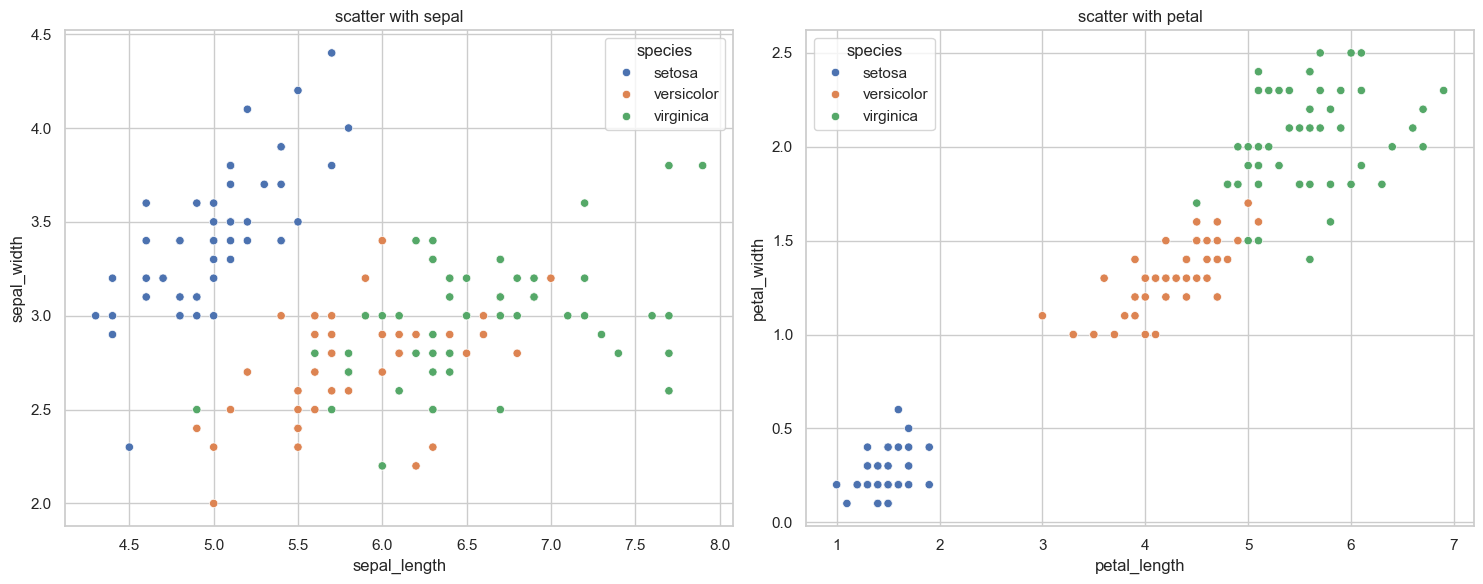

In [37]:
# iris dataset 
iris = sns.load_dataset('iris')

print(iris.shape)
display(iris.head())

fig, axes = plt.subplots(1,2,figsize=(15,6))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species', ax=axes[0])
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=axes[1])
axes[0].set_title('scatter with sepal')
axes[1].set_title('scatter with petal')

plt.tight_layout()
plt.show()

In [6]:
# species 값이 없다고 가정 
df = iris.drop('species', axis=1)

# 스케일 표준화 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = df.columns
df[cols] = scaler.fit_transform(df[cols])

#### Elbow method 

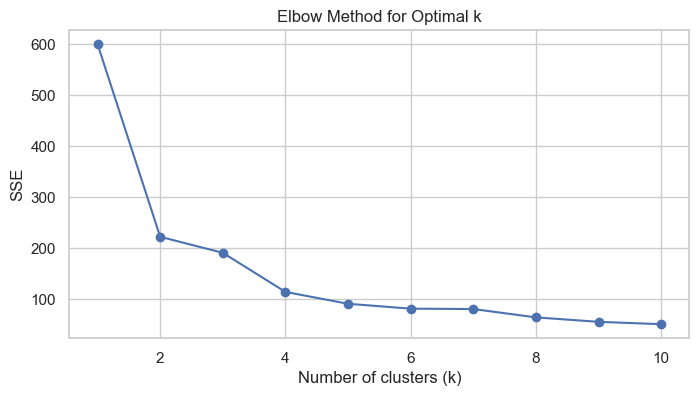

In [23]:
from sklearn.cluster import KMeans

wcss = []  
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)  # inertia_: 군집 내 거리 제곱합

plt.figure(figsize=(8,4))
plt.plot(K_range, wcss, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

- k = 2~4 사이의 값이 되면 좋을 듯
- 실루엣 점수로 좀더 정교화 해보자 

#### Silhoutte score

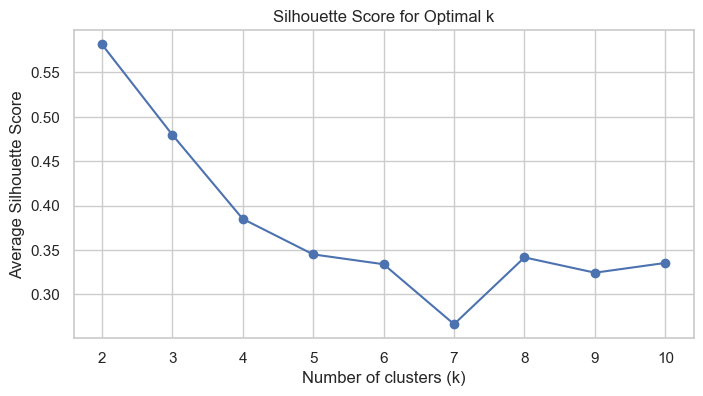

In [24]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,4))
plt.plot(range(2,11), sil_scores, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

- k=2일때 최적의 클러스터링 

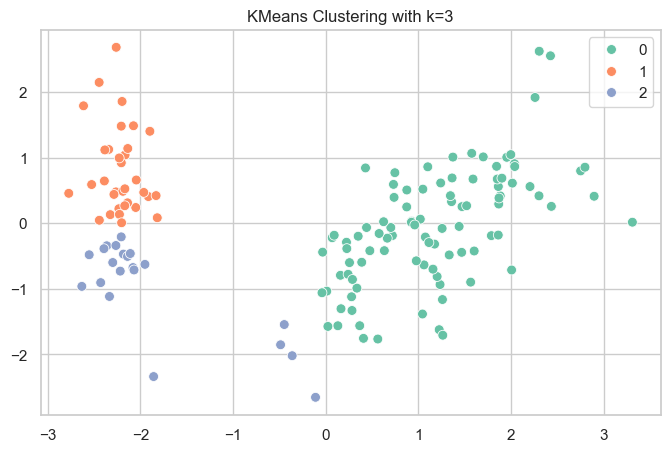

In [38]:
k = 3

kmeans_opt = KMeans(n_clusters=k, random_state=42)
labels_opt = kmeans_opt.fit_predict(df)

from sklearn.decomposition import PCA
X_pca2 = PCA(n_components=2).fit_transform(df)

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=labels_opt, palette='Set2', s=50)
plt.title(f"KMeans Clustering with k={k}")
plt.show()

### DB Scan

,x1,x2,label
0,-1.020690,0.105518,0
1,0.905826,0.457858,0
2,0.618422,0.757086,0
3,1.227707,-0.425185,1
4,0.329356,-0.206946,1


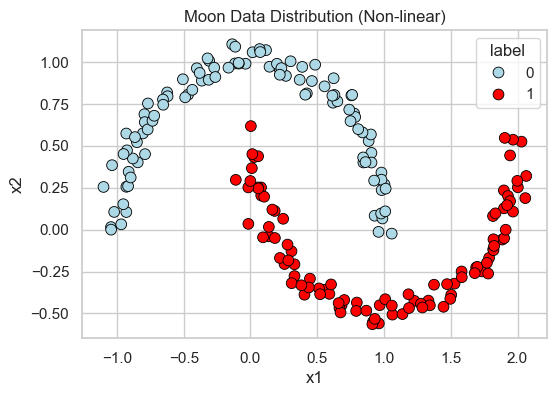

In [53]:
# 비선형 - 반달 모양 데이터 생성
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['label'] = y.astype(str)  
display(df.head())

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='x1', y='x2', hue='label', palette=['lightblue','red'], s=60, edgecolor='black')
plt.title('Moon Data Distribution (Non-linear)')
plt.show()

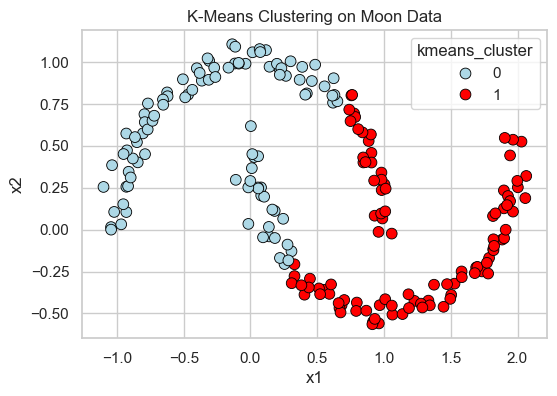

In [54]:
# Try 1 : KMeans 클러스터링 (n_clusters=2)
km = KMeans(n_clusters=2, n_init=10, random_state=42)
y_km = km.fit_predict(X)

# 데이터프레임에 클러스터 결과 추가
df['kmeans_cluster'] = y_km.astype(str)

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='x1', y='x2', hue='kmeans_cluster',
                palette=['lightblue','red'], s=60, edgecolor='black')
plt.title('K-Means Clustering on Moon Data')
plt.show()

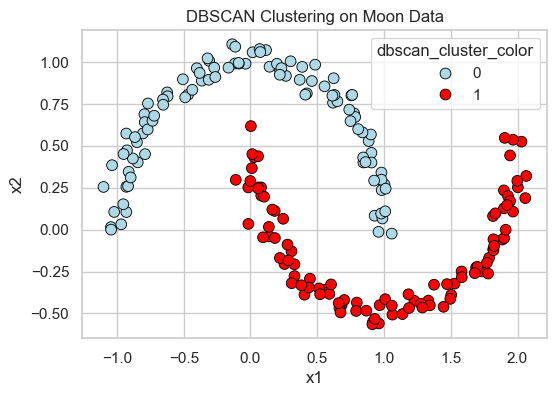

In [56]:
# Try 2 : DBSCAN 클러스터링
db = DBSCAN(eps=0.2, min_samples=5)
y_db = db.fit_predict(X)

# 데이터프레임에 클러스터 결과 추가
df['dbscan_cluster'] = y_db.astype(str)
df['dbscan_cluster_color'] = df['dbscan_cluster']

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='x1', y='x2', hue='dbscan_cluster_color',
                palette={'0':'lightblue', '1':'red', 'noise':'gray'},
                s=60, edgecolor='black')
plt.title('DBSCAN Clustering on Moon Data')
plt.show()